## Importação das bibliotecas

In [42]:
%pip install seaborn
%matplotlib inline

In [43]:
import pandas as pd
import seaborn as sb
import numpy as np
import statsmodels.api as sm
import shap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, f1_score, classification_report
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

## Análise exploratória dos dados

In [44]:
dados = pd.read_csv('/content/data.csv', sep=',')
df = pd.read_csv('/content/data.csv', sep=',')
dados = dados.loc[:, ~dados.columns.str.contains('^Unnamed')]
df = dados.loc[:, ~dados.columns.str.contains('^Unnamed')]

Realizei a leitura do dataset utilizando a biblioteca do pandas. Além disso, rodei um script para remover a coluna "Unnamed" criada indevidamente, pois tinha uma vírgula extra no csv. Foram criadas duas variáveis para receber nosso dataset pois uma terá a target tratada com LabelEncoder e a outra não. A análise SHAP estava saindo errada com o campo tratado, então utilizarei uma apenas para matriz de correlação e a outra pras demais operações.

In [88]:
dados.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Rodei o script dados.head() para validar a estrutura do dataset e conferir como os registros estavam disponibilizados.

In [89]:
dados.groupby('diagnosis').mean()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,2.654382e+07,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
M,3.681805e+07,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


Fiz um agrupamento dos dados por diagnóstico ('B' - Benigno e 'M' - Maligno) para validar, ainda por cima, como estão as médias dos valores das features. Podemos considerar que valores maiores tendem a ser um tumor maligno. Com esse agrupamento, também confirmamos que não existe outro valor de diagnosis no dataset além de 'M' e 'B'.

In [47]:
dados.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


Faço uma contagem de valores nulos para validar se precisamos de tratativa ou não na base de dados. Nesse caso, não será necessário.

In [48]:
colunas=['diagnosis']

label_encoder = LabelEncoder()
for col in colunas:
    df[col] = label_encoder.fit_transform(df[col])
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Para plotar a matriz de correlação, é necessário que todos os valores sejam numéricos. Utilizei então o LabelEncoder para transformar nossa variável target em 0 ou 1. Pela ordem alfabética, o valor "B" se transforma em 0 e o "M" em 1.


<Axes: >

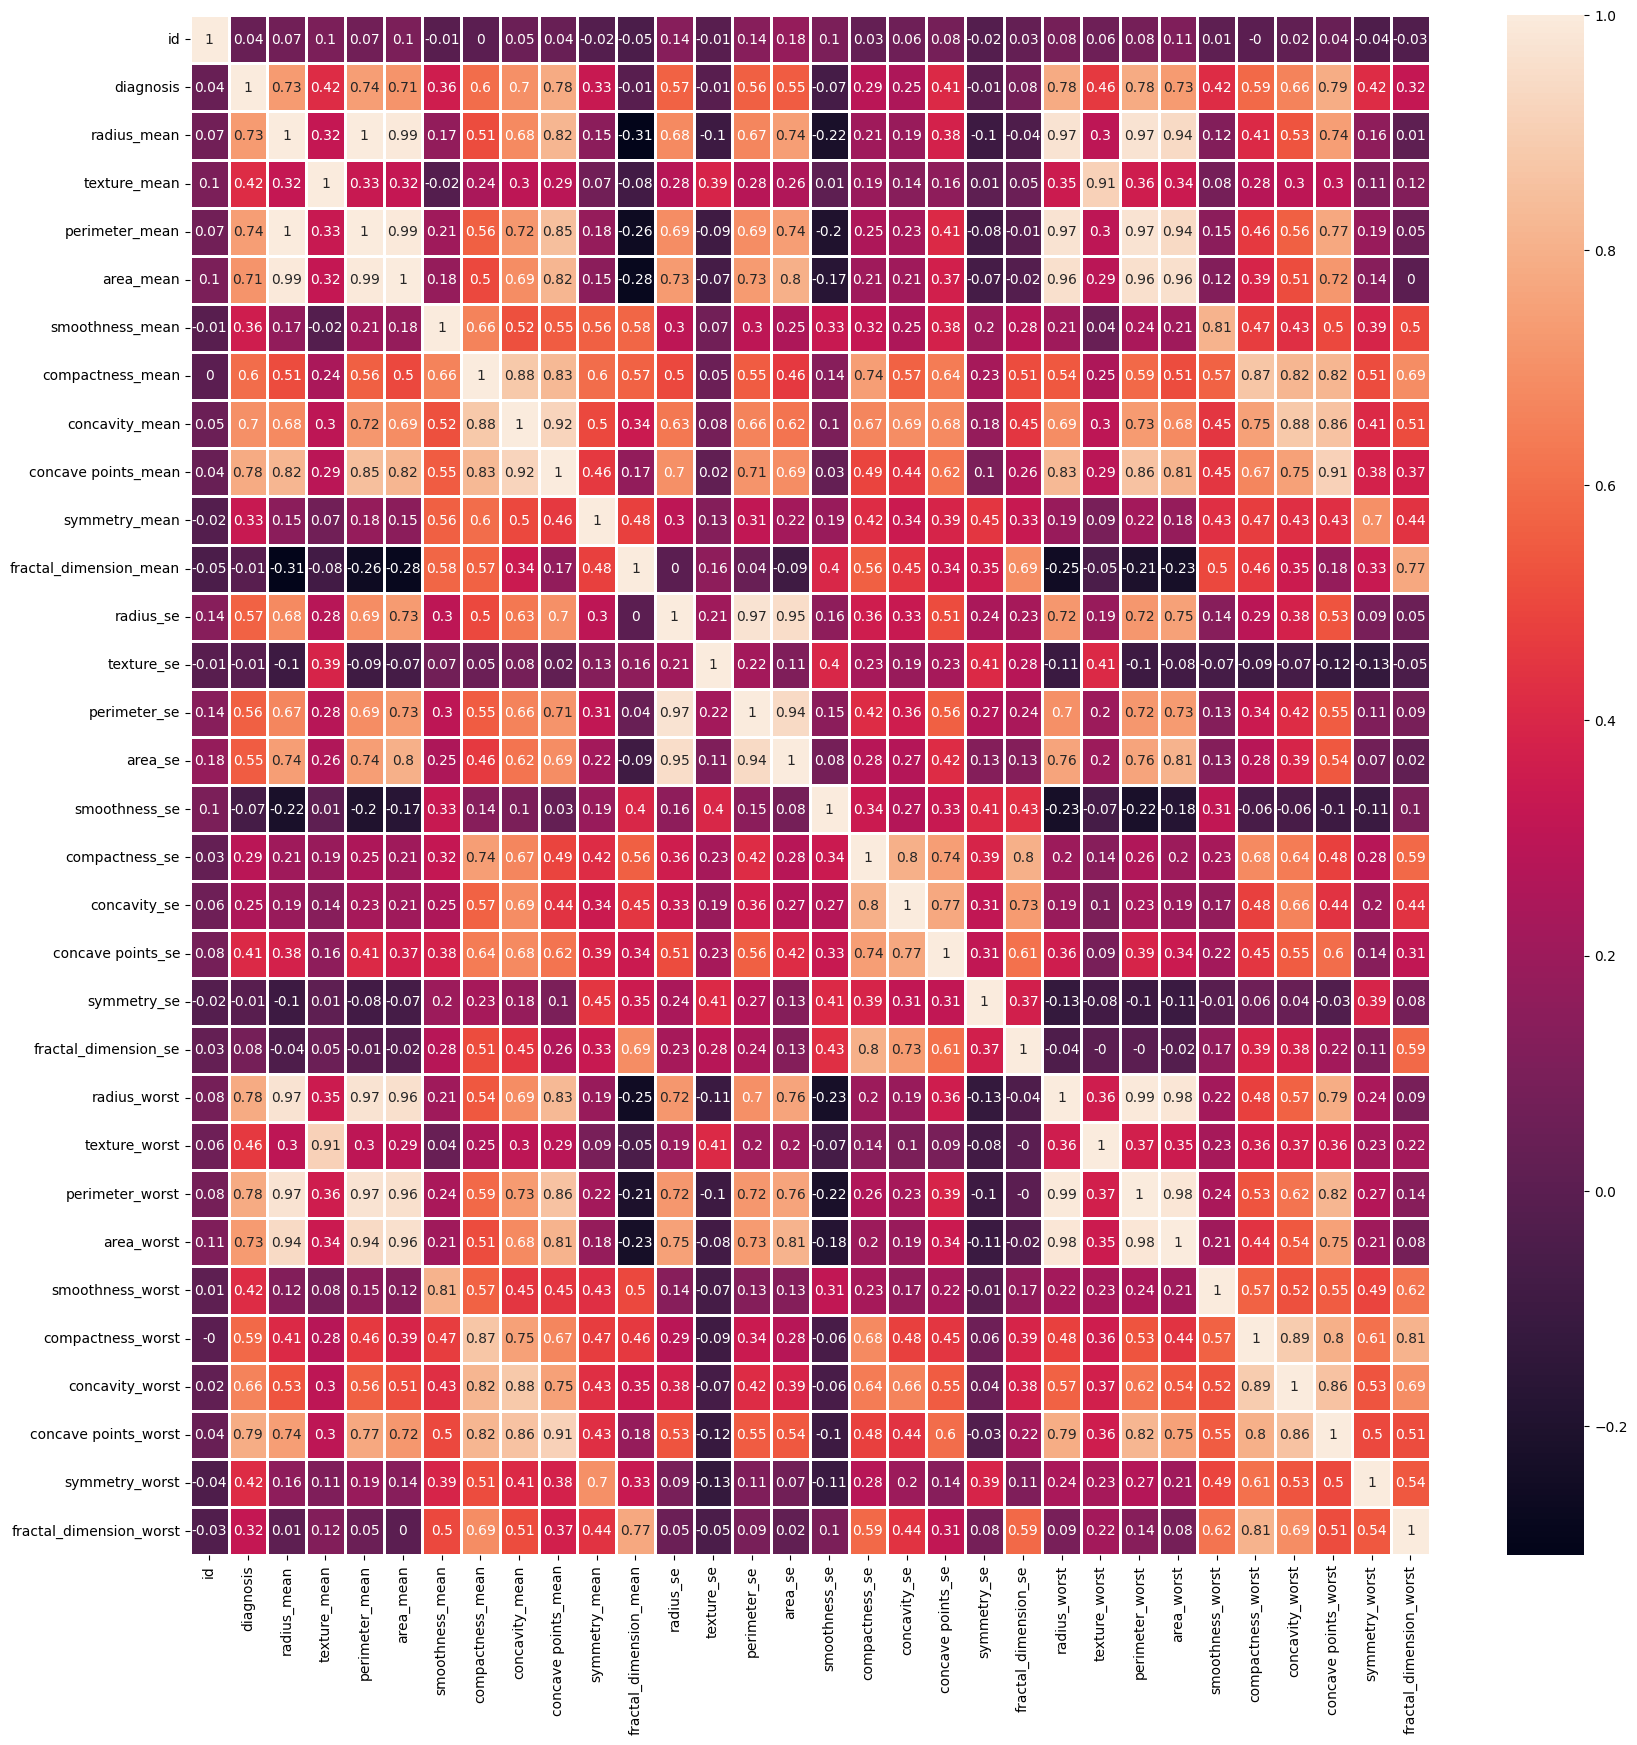

In [49]:
correlation_matrix = df.corr().round(2)

fig, ax = plt.subplots(figsize=(20,20))
sb.heatmap(data=correlation_matrix, annot=True, linewidths=1, ax=ax)

Realizando a análise de correlação, onde o valor estar mais próximo de 1 significa maior chance de ser um tumor maligno (pois M = 1). Plotei a matriz com figsize 20 para comportar todas as nossas variáveis. É possível analisar que 4 variáveis possuem uma maior correlação com nossa target diagnosis:
"concave points_mean", "radius_worst", "perimeter_worst" e "concave points_worst", com valor 0.79/0.78. Vou analisar mais a fundo cada uma.

<Axes: xlabel='diagnosis', ylabel='concave points_mean'>

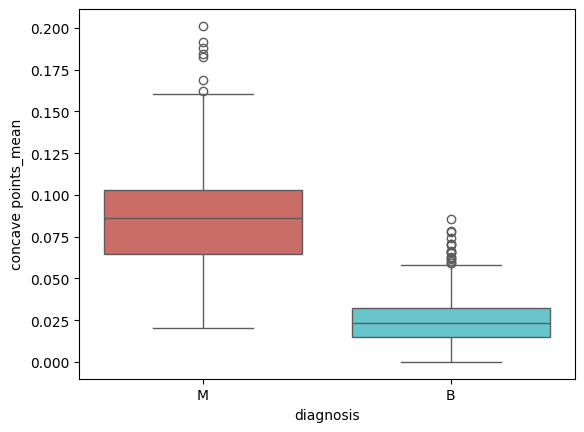

In [50]:
sb.boxplot(x='diagnosis', y='concave points_mean', data=dados, palette='hls', hue="diagnosis", legend=False)

<Axes: xlabel='concave points_mean', ylabel='Count'>

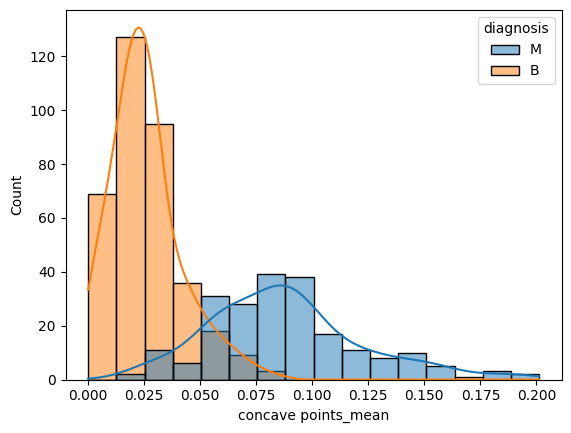

In [51]:
sb.histplot(data=dados, x='concave points_mean', hue='diagnosis', kde=True)

Aqui visualizamos, com as informações dos gráficos da feature concave points_mean, que existe bastante outliers acima da média (0.025) no diagnóstico benigno. Levando em consideração o gráfico de histograma, a partir do valor 0.050 já temos um ponto de atenção, pois chega no mínimo do diagnóstico maligno. Ainda assim, o mais interessante disso tudo é que um valor mais que triplicado da média benigna ainda não é suficiente para determinar o tipo de tumor, por isso é necessário análise de outras variáveis.

<Axes: xlabel='diagnosis', ylabel='radius_worst'>

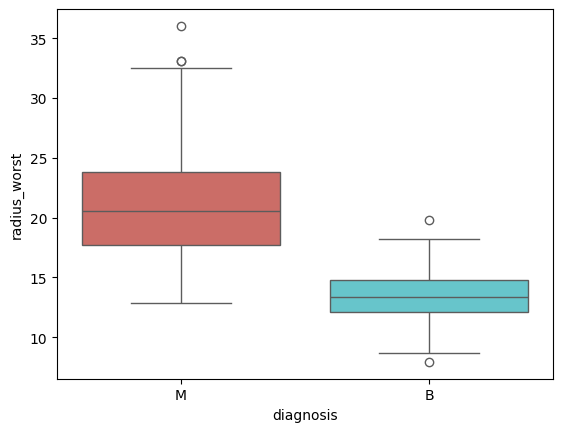

In [52]:
sb.boxplot(x='diagnosis', y='radius_worst', data=dados, palette='hls', hue="diagnosis", legend=False)

<Axes: xlabel='radius_worst', ylabel='Count'>

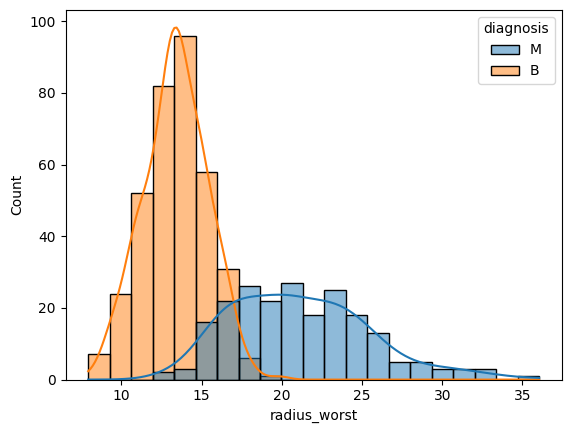

In [53]:
sb.histplot(data=dados, x='radius_worst', hue='diagnosis', kde=True)

<Axes: xlabel='diagnosis', ylabel='perimeter_worst'>

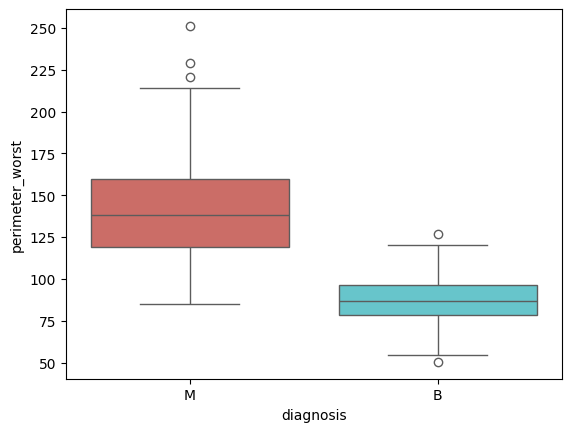

In [54]:
sb.boxplot(x='diagnosis', y='perimeter_worst', data=dados, palette='hls', hue="diagnosis", legend=False)

<Axes: xlabel='perimeter_worst', ylabel='Count'>

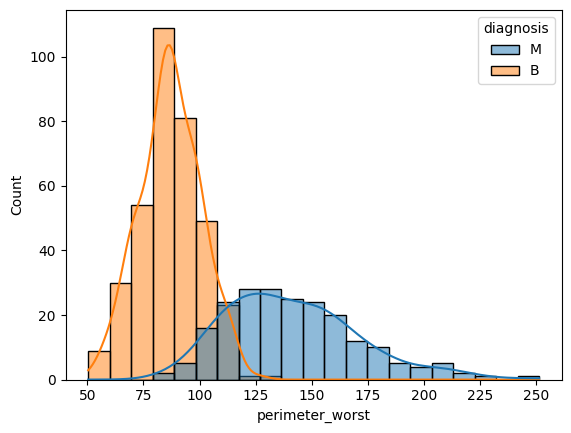

In [55]:
sb.histplot(data=dados, x='perimeter_worst', hue='diagnosis', kde=True)

<Axes: xlabel='diagnosis', ylabel='concave points_worst'>

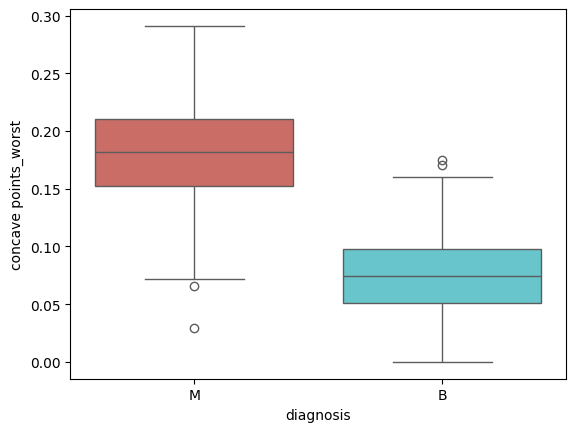

In [56]:
sb.boxplot(x='diagnosis', y='concave points_worst', data=dados, palette='hls', hue="diagnosis", legend=False)

<Axes: xlabel='concave points_worst', ylabel='Count'>

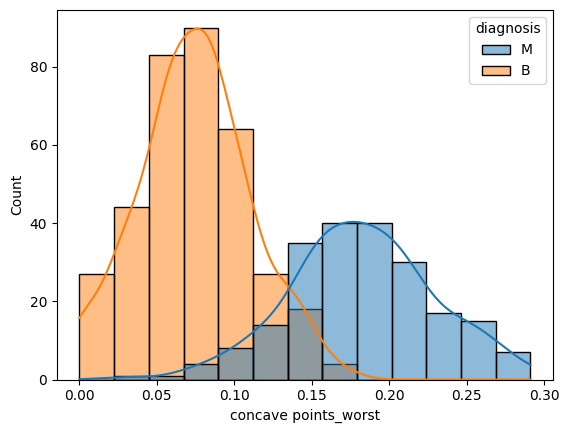

In [57]:
sb.histplot(data=dados, x='concave points_worst', hue='diagnosis', kde=True)

Analisando as outras 3 variáveis com maior correlação com nossa target, o comportamento é mais padronizado, com pouquíssimos outliers. Com os histogramas dessas features, notamos que a partir de um certo valor dentro da escala, ela muda o diagnóstico de benigno para maligno, conforme cresce a variável. Ainda assim, vemos alguns com o valor mínimo batendo com a média do diagnóstico oposto, então não podemos considerar apenas 1 feature como verdade absoluta.

# Pré-Processamento de dados + Separação de bases (treino e teste)

In [58]:
x = dados[["concave points_mean", "radius_worst", "perimeter_worst", "concave points_worst"]]
y = dados["diagnosis"]

Iniciando o processo de pré-processamento de dados. Não teremos necessidade de popular valores nulos.

In [59]:
x

,concave points_mean,radius_worst,perimeter_worst,concave points_worst
0,0.14710,25.380,184.60,0.2654
1,0.07017,24.990,158.80,0.1860
2,0.12790,23.570,152.50,0.2430
3,0.10520,14.910,98.87,0.2575
4,0.10430,22.540,152.20,0.1625
...,...,...,...,...
564,0.13890,25.450,166.10,0.2216
565,0.09791,23.690,155.00,0.1628
566,0.05302,18.980,126.70,0.1418
567,0.15200,25.740,184.60,0.2650


In [60]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

Setando a quantidade de dados que serão usados para treino e teste. Com o test_size 0.2, 20% da base será utilizada para validação do modelo treinado.


In [61]:
x_train.shape

(455, 4)

In [62]:
x_test.shape

(114, 4)

In [63]:
scaler = StandardScaler()

scaler.fit(x_train)

x_train_escalonado = scaler.transform(x_train)
x_test_escalonado = scaler.transform(x_test)

Realizo a validação com shape() para confirmar que temos a quantidade certa de registros nas bases. Além disso, é muito importante realizar o escalonamento dos dados com o StandardScaler para evitar que os modelos, principalmente KNN e SVM, sofram com os outliers.

In [64]:
x_train_escalonado

array([[-0.39817525,  0.5797977 ,  0.46690813, -0.23574392],
       [-0.30307491, -0.58245895, -0.61193429, -0.32320788],
       [-0.76545935, -0.39862222, -0.47543128, -0.89082504],
       ...,
       [-0.79194618, -0.41087801, -0.492128  , -0.84289958],
       [-0.46502298,  0.02011699,  0.124186  ,  0.27571059],
       [ 1.26948625,  0.94747115,  1.03518245,  1.00657384]])

# Configuração e treinamento dos modelos

Foram selecionados os modelos KNN, SVM e Random Forest por representarem diferentes abordagens de aprendizado de máquina. O KNN é um método baseado em instâncias, o SVM busca maximizar a margem de separação entre classes, e o Random Forest utiliza um conjunto de árvores de decisão para melhorar a generalização. Além disso, esses modelos são adequados para bases de dados de tamanho reduzido.

In [90]:
rf = Pipeline(
    [
      ("model", RandomForestClassifier(random_state=42))
    ]
)

In [91]:
rf.fit(x_train_escalonado, y_train)

Pipeline(steps=[('model', RandomForestClassifier(random_state=42))])

In [92]:
y_predito_rf = rf.predict(x_test_escalonado)

In [93]:
svm = Pipeline(
    [
        ("linear_svc", LinearSVC(C=1))
    ]
)

In [94]:
svm.fit(x_train_escalonado, y_train)

Pipeline(steps=[('linear_svc', LinearSVC(C=1))])

In [95]:
y_predito_svm = svm.predict(x_test_escalonado)

Criadas as pipelines para os modelos Random Forest e SVM. No caso do KNN, irei fazer uma plotagem de um gráfico de erro médio para analisar a melhor quantidade de vizinhos para usar.

In [71]:
error = []

for i in range(1,10):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_escalonado, y_train)
    pred_i = knn.predict(x_test_escalonado)
    error.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Erro médio')

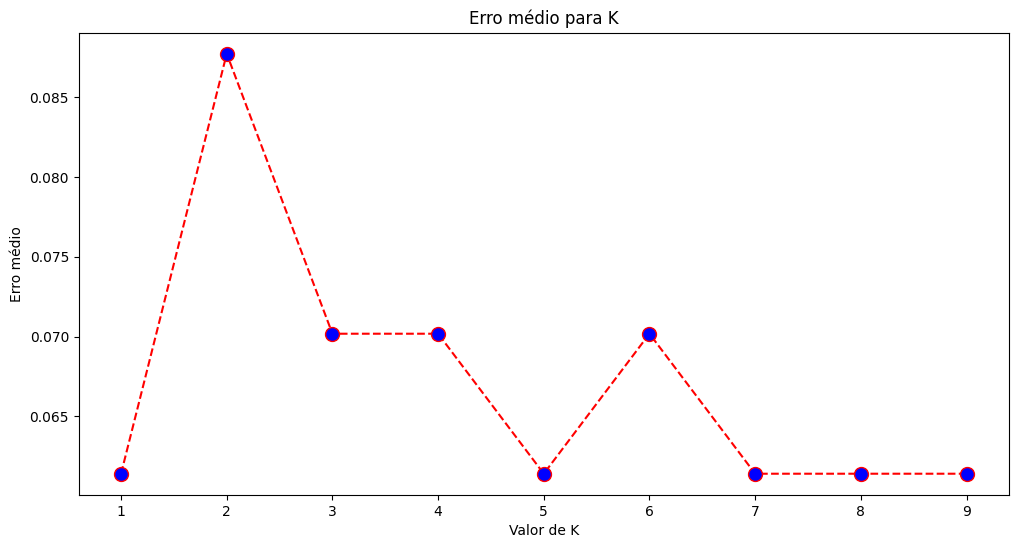

In [72]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 10), error, color="red", linestyle="dashed", marker="o", markerfacecolor="blue", markersize=10)
plt.title("Erro médio para K")
plt.xlabel("Valor de K")
plt.ylabel("Erro médio")

In [73]:
modelo_knn = KNeighborsClassifier(n_neighbors=9)

modelo_knn.fit(x_train_escalonado, y_train)

y_predito_knn = modelo_knn.predict(x_test_escalonado)

In [74]:
y_predito_knn

array(['B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B',
       'B', 'B', 'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M',
       'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B',
       'B', 'M', 'M', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M',
       'B', 'M', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'M', 'M', 'B', 'M',
       'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'M'], dtype=object)

Realizei um for de 1 até 9 para validarmos o melhor valor de K para utilizarmos. Nesse caso, os valores com menor média de erro padrão é o 5, 7, 8 e 9. Selecionei o 9 pois é um valor ímpar com o maior número de vizinhos, mas poderia ser o 5 ou o 7.

# Avaliação dos modelos

In [96]:
#Validando acurácia do treinamento utilizando Random Forest
print(accuracy_score(y_test, y_predito_rf))

0.9473684210526315


In [97]:
#Validando acurácia do treinamento utilizando SVM
print(accuracy_score(y_test, y_predito_svm))

0.956140350877193


In [98]:
#Validando acurácia do treinamento utilizando KNN
print(accuracy_score(y_test, y_predito_knn))

0.9385964912280702


Utilizando apenas a métrica accuracy_score, o modelo SVM é o mais preciso. Entretanto, é necessário avaliar de outras formas.

In [78]:
#Avaliação do modelo RF
print(classification_report(y_test, y_predito_rf))

              precision    recall  f1-score   support

           B       0.95      0.97      0.96        72
           M       0.95      0.90      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [79]:
#Avaliação do modelo SVM
print(classification_report(y_test, y_predito_svm))

              precision    recall  f1-score   support

           B       0.96      0.97      0.97        72
           M       0.95      0.93      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [80]:
#Avaliação do modelo KNN
print(classification_report(y_test, y_predito_knn))

              precision    recall  f1-score   support

           B       0.92      0.99      0.95        72
           M       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



Pelo classification_report, temos uma análise interessante a fazer: O modelo KNN teve um pouco de dificuldade, em comparação com os outros modelos, no precision de diagnóstico benigno e também no recall do maligno, ainda que seja uma taxa altíssima de acerto. Todos os 3 modelos tiveram uma porcentagem acima de 90%, com o SVM tendo o melhor desempenho.

In [81]:
kfold  = KFold(n_splits=5, shuffle=True)
result_rf = cross_val_score(rf, x, y, cv = kfold)
result_svm = cross_val_score(svm, x, y, cv = kfold)
result_knn = cross_val_score(modelo_knn, x, y, cv = kfold)

print("Média R^2 do modelo RF: {0}".format(result_rf.mean()))
print("Média R^2 do modelo SVM: {0}".format(result_svm.mean()))
print("Média R^2 do modelo KNN: {0}".format(result_knn.mean()))

Média R^2 do modelo RF: 0.947290793355069
Média R^2 do modelo SVM: 0.9314547430523211
Média R^2 do modelo KNN: 0.9050768514205869


Aplicando a validação cruzada, a taxa de R^2 de todos os modelos fica acima de 90%. Irei aplicar o GridSearch no modelo KNN e ver como seria o comportamento com hiperparâmetros otimizados.

In [82]:
error = []

for i in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_escalonado, y_train)
    pred_i = knn.predict(x_test_escalonado)
    error.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Mean Error')

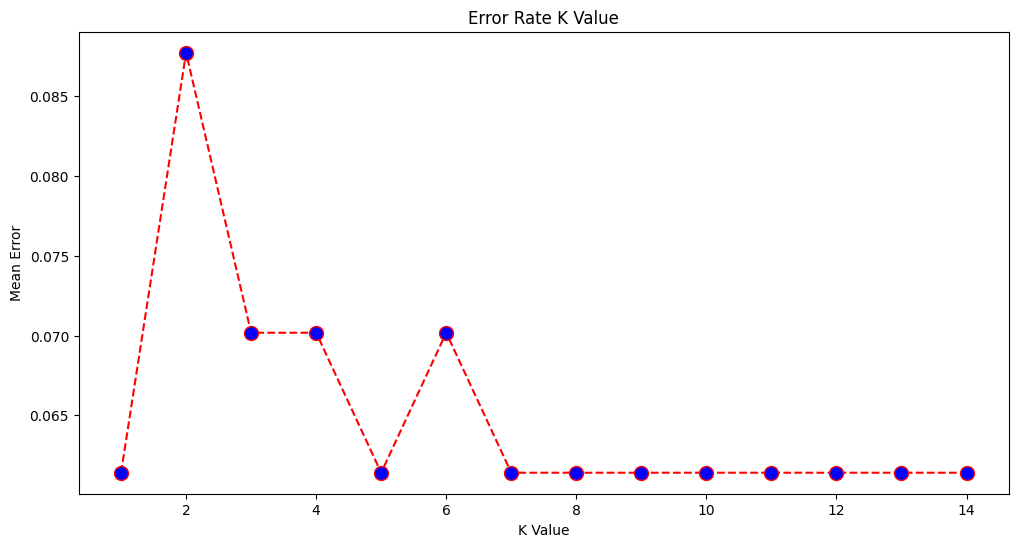

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 15), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [84]:
param_grid = {'n_neighbors':[5,7,8,9,10,11,12,13,14],
              'weights': ['uniform', 'distance'],
              'metric':['cosine', 'euclidean', 'manhattan']
             }

gs_metric = make_scorer(accuracy_score, greater_is_better=True)

grid = GridSearchCV(KNeighborsClassifier(),
                    param_grid=param_grid,
                    scoring=gs_metric,
                    cv=5, n_jobs=4, verbose=3)

grid.fit(x_train_escalonado, y_train)
knn_params = grid.best_params_
print('KNN', knn_params)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
KNN {'metric': 'cosine', 'n_neighbors': 5, 'weights': 'uniform'}


Pelo GridSearch, a melhor configuração do KNN é utilizando os parâmetros {'metric': 'cosine', 'n_neighbors': 5, 'weights': 'uniform'}. Vou aplicá-los no modelo.

In [85]:
knn_novo = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='cosine')
knn_novo.fit(x_train_escalonado, y_train)

y_predito_knn_novo = knn_novo.predict(x_test_escalonado)

In [86]:
print("Accuracy score final do KNN: ", accuracy_score(y_test, y_predito_knn))
print(classification_report(y_test, y_predito_knn))

Accuracy score final do KNN:  0.9385964912280702
              precision    recall  f1-score   support

           B       0.92      0.99      0.95        72
           M       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



No fim, tivemos 3 modelos com boa taxa de acerto. Por ter resultados mais confiáveis e equilibrados (acima de 93% em todos os métodos de avaliação), o SVM seria a opção que eu escolheria. O recall do diagnóstico tem que ser o mais assertivo possível, pois deixar passar uma pessoa doente erroneamente pode significar risco à vida.  

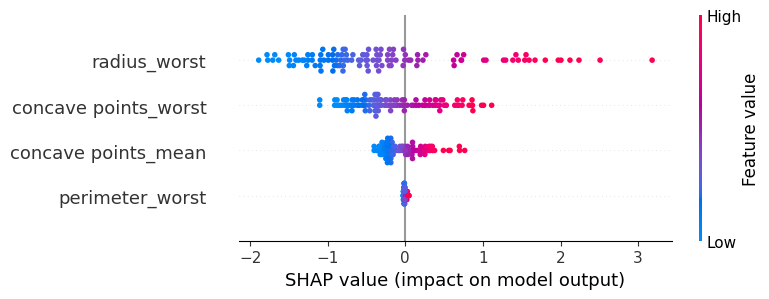

In [87]:
x_train_escalonado_df = pd.DataFrame(x_train_escalonado, columns=x.columns)
x_test_escalonado_df = pd.DataFrame(x_test_escalonado, columns=x.columns)

explainer = shap.LinearExplainer(svm.named_steps['linear_svc'], x_train_escalonado_df)

shap_values = explainer.shap_values(x_test_escalonado_df)

shap.summary_plot(shap_values, x_test_escalonado_df)

Aplicando a análise SHAP no modelo SVM, podemos notar um ponto que complementa nosso raciocínio durante a análise exploratória: a feature concave points_mean é a terceira na lista de importância no diagnóstico, o que indica que ela não tem tanto impacto quanto as outras. Ainda que não dê pra desconsiderar completamente o seu valor, os outliers presentes no gráfico boxplot acabam mostrando que ela depende muito de outras variáveis para indicar um resultado.

# Conclusão

Neste tech-challenge, foi desenvolvido um script de análise de dados e modelagem preditiva com o objetivo de identificar padrões associados à saúde feminina, utilizando técnicas de aprendizado de máquina para classificação. A análise exploratória permitiu compreender a distribuição das variáveis e identificar relações relevantes entre atributos clínicos, destacando fatores potencialmente associados ao risco analisado.

Durante o pré-processamento, os dados foram tratados e padronizados para garantir consistência e melhor desempenho dos modelos. A aplicação de diferentes algoritmos de classificação (como KNN, SVM e Random Forest) possibilitou comparar abordagens distintas.

Na etapa de avaliação, métricas como accuracy, recall e F1-score foram utilizadas. Dentre elas, o recall se mostrou especialmente importante, considerando o contexto de saúde: minimizar falsos negativos é essencial, pois a não identificação de um caso positivo pode atrasar o tratamento, às vezes crítico. Os resultados indicam que o modelo possui boa capacidade preditiva, mas ainda apresenta limitações que devem ser consideradas.

A utilização de técnicas de explicabilidade, como SHAP, contribuiu para maior transparência do modelo, permitindo identificar quais variáveis exercem maior influência nas previsões. Isso é fundamental em aplicações na área da saúde, onde a interpretabilidade é tão importante quanto a performance.

Apesar dos resultados promissores, este modelo não deve ser utilizado de forma isolada na prática clínica. Ele pode atuar como uma ferramenta de apoio à decisão, auxiliando profissionais de saúde na triagem e priorização de casos, mas não substitui a avaliação médica. Além disso, é importante destacar limitações como o tamanho e a representatividade da base de dados, possíveis vieses e a necessidade de validação com dados reais e mais diversos.